In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/Multimedia_Authentication"

FACES_DIR = os.path.join(PROJECT_DIR, "faces")
PROCESSED_SPLIT_FILE = os.path.join(
    PROJECT_DIR,
    "splits",
    "ffpp_2647_processed_split.csv"
)

print("Project directory:", PROJECT_DIR)
print("Faces directory:", FACES_DIR)
print("Split file:", PROCESSED_SPLIT_FILE)

print("\nFaces directory exists:", os.path.exists(FACES_DIR))
print("Split file exists:", os.path.exists(PROCESSED_SPLIT_FILE))

Project directory: /content/drive/MyDrive/Multimedia_Authentication
Faces directory: /content/drive/MyDrive/Multimedia_Authentication/faces
Split file: /content/drive/MyDrive/Multimedia_Authentication/splits/ffpp_2647_processed_split.csv

Faces directory exists: True
Split file exists: True


In [3]:
df = pd.read_csv(PROCESSED_SPLIT_FILE)

print("Total videos:", len(df))

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nLabel distribution:")
print(df["Label"].value_counts())

print("\nSplit × Label:")
print(pd.crosstab(df["split"], df["Label"]))

print("\nColumns:")
print(df.columns.tolist())

Total videos: 2647

Split distribution:
split
train    1822
test      424
val       401
Name: count, dtype: int64

Label distribution:
Label
FAKE    2211
REAL     436
Name: count, dtype: int64

Split × Label:
Label  FAKE  REAL
split            
test    359    65
train  1519   303
val     333    68

Columns:
['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)', 'source_id', 'split', 'npz_name', 'extracted']


In [4]:
face_files = {
    f for f in os.listdir(FACES_DIR)
    if f.endswith(".npz")
}

print("Actual face NPZ files:", len(face_files))

Actual face NPZ files: 2580


In [5]:
def make_output_name(file_path):
    return file_path.replace("/", "__").replace("\\", "__").replace(".mp4", ".npz")


df["face_file"] = df["File Path"].apply(make_output_name)

df["face_exists"] = df["face_file"].isin(face_files)

print("\nFace files available:")
print(df["face_exists"].value_counts())

print("\nMissing face files by split:")
print(
    df.loc[~df["face_exists"], "split"]
    .value_counts()
)

print("\nMissing face files by label:")
print(
    df.loc[~df["face_exists"], "Label"]
    .value_counts()
)


Face files available:
face_exists
True     2580
False      67
Name: count, dtype: int64

Missing face files by split:
split
train    52
val       9
test      6
Name: count, dtype: int64

Missing face files by label:
Label
FAKE    61
REAL     6
Name: count, dtype: int64


In [6]:
sample_row = df[df["face_exists"]].iloc[0]

face_path = os.path.join(
    FACES_DIR,
    sample_row["face_file"]
)

data = np.load(face_path)

print("Video:", sample_row["File Path"])
print("Label:", sample_row["Label"])
print("Split:", sample_row["split"])
print("NPZ keys:", data.files)

frames = data["frames"]

print("Frames shape:", frames.shape)
print("Frames dtype:", frames.dtype)
print("Min:", frames.min())
print("Max:", frames.max())

Video: FaceShifter/424_408.mp4
Label: FAKE
Split: train
NPZ keys: ['frames']
Frames shape: (8, 224, 224, 3)
Frames dtype: uint8
Min: 0
Max: 221


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FaceSequenceDataset(Dataset):

    def __init__(self, dataframe, faces_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.faces_dir = faces_dir
        self.transform = transform

        # Label mapping
        self.label_map = {
            "REAL": 0,
            "FAKE": 1
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        npz_name = make_output_name(row["File Path"])
        npz_path = os.path.join(
            self.faces_dir,
            npz_name
        )

        # Load 8 face frames
        data = np.load(npz_path)
        frames = data["frames"]

        # (8, 224, 224, 3) → 8 individual images
        processed_frames = []

        for frame in frames:

            # uint8 NumPy → PIL image
            from PIL import Image

            image = Image.fromarray(frame)

            if self.transform:
                image = self.transform(image)

            processed_frames.append(image)

        # (8, 3, 224, 224)
        frames = torch.stack(processed_frames)

        label = self.label_map[row["Label"]]

        return frames, torch.tensor(label, dtype=torch.long)

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_df = df[
    (df["split"] == "train") &
    (df["face_exists"])
].copy()

val_df = df[
    (df["split"] == "val") &
    (df["face_exists"])
].copy()

test_df = df[
    (df["split"] == "test") &
    (df["face_exists"])
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1770
Validation: 392
Test: 418


In [10]:
train_df = df[
    (df["split"] == "train") &
    (df["face_exists"])
].copy()

val_df = df[
    (df["split"] == "val") &
    (df["face_exists"])
].copy()

test_df = df[
    (df["split"] == "test") &
    (df["face_exists"])
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1770
Validation: 392
Test: 418


In [11]:
train_dataset = FaceSequenceDataset(
    train_df,
    FACES_DIR,
    transform=transform
)

val_dataset = FaceSequenceDataset(
    val_df,
    FACES_DIR,
    transform=transform
)

test_dataset = FaceSequenceDataset(
    test_df,
    FACES_DIR,
    transform=transform
)

In [12]:
frames, label = train_dataset[0]

print("Frames shape:", frames.shape)
print("Frames dtype:", frames.dtype)
print("Label:", label)

Frames shape: torch.Size([8, 3, 224, 224])
Frames dtype: torch.float32
Label: tensor(1)


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

frames, labels = next(iter(train_loader))

print("Batch frames:", frames.shape)
print("Batch labels:", labels.shape)
print("Labels:", labels)

Batch frames: torch.Size([4, 8, 3, 224, 224])
Batch labels: torch.Size([4])
Labels: tensor([1, 0, 1, 1])


In [14]:
print("TRAIN")
print(train_df["Label"].value_counts())

print("\nVALIDATION")
print(val_df["Label"].value_counts())

print("\nTEST")
print(test_df["Label"].value_counts())

TRAIN
Label
FAKE    1472
REAL     298
Name: count, dtype: int64

VALIDATION
Label
FAKE    324
REAL     68
Name: count, dtype: int64

TEST
Label
FAKE    354
REAL     64
Name: count, dtype: int64


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


In [17]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 222
Validation batches: 49
Test batches: 53


In [18]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

In [19]:
weights = ResNet18_Weights.DEFAULT

resnet = resnet18(weights=weights)

# Remove the original ImageNet classification layer
feature_extractor = nn.Sequential(
    *list(resnet.children())[:-1]
)

print(feature_extractor)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.3MB/s]

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [20]:
class SpatialResNet18(nn.Module):

    def __init__(self):
        super().__init__()

        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

        # ResNet18 feature extractor
        self.backbone = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        # Video-level classifier
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        """
        x shape:
        [batch, 8, 3, 224, 224]
        """

        batch_size, num_frames, C, H, W = x.shape

        # Combine batch and frame dimensions
        x = x.view(
            batch_size * num_frames,
            C,
            H,
            W
        )

        # Extract frame-level features
        features = self.backbone(x)

        # [B*8, 512, 1, 1] → [B, 8, 512]
        features = features.view(
            batch_size,
            num_frames,
            512
        )

        # Mean pooling across the 8 frames
        video_features = features.mean(dim=1)

        # Binary classification
        logits = self.classifier(video_features)

        return logits

In [21]:
model = SpatialResNet18().to(device)

print(model)

SpatialResNet18(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [22]:
class_counts = train_df["Label"].value_counts()

real_count = class_counts["REAL"]
fake_count = class_counts["FAKE"]

total = real_count + fake_count

class_weights = torch.tensor(
    [
        total / (2 * real_count),   # REAL
        total / (2 * fake_count)    # FAKE
    ],
    dtype=torch.float32
).to(device)

print("Class weights:")
print("REAL:", class_weights[0].item())
print("FAKE:", class_weights[1].item())

Class weights:
REAL: 2.9697985649108887
FAKE: 0.601222813129425


In [23]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [24]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

## 6. Training the Spatial ResNet18 Baseline

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import time
import copy

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):

    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for frames, labels in loader:

        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.amp.autocast(device_type="cuda"):
                logits = model(frames)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(frames)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_acc = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_acc

In [27]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for frames, labels in loader:

            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(frames)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1]

            preds = torch.argmax(logits, dim=1)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    auc = roc_auc_score(
        all_labels,
        all_probs
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

In [28]:
NUM_EPOCHS = 10

scaler = torch.amp.GradScaler("cuda")

best_val_f1 = -1
best_epoch = 0
best_model_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        scaler
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_metrics["loss"])

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_auc"].append(val_metrics["auc"])

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Time: {epoch_time:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
    )

    # Save best model based on validation F1
    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_f1": best_val_f1
            },
            os.path.join(
                PROJECT_DIR,
                "spatial_resnet18_best.pth"
            )
        )

        print("  ✓ Best model saved")

total_time = time.time() - start_time

print("\nTraining complete.")
print(f"Total training time: {total_time / 60:.2f} minutes")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch [1/10] | Time: 1095.8s | Train Loss: 0.7493 | Train Acc: 0.6237 | Val Loss: 0.6658 | Val Acc: 0.5740 | Val Precision: 0.8905 | Val Recall: 0.5525 | Val F1: 0.6819 | Val AUC: 0.6426
  ✓ Best model saved
Epoch [2/10] | Time: 46.6s | Train Loss: 0.6209 | Train Acc: 0.7226 | Val Loss: 0.7039 | Val Acc: 0.5791 | Val Precision: 0.9251 | Val Recall: 0.5340 | Val F1: 0.6771 | Val AUC: 0.7534
Epoch [3/10] | Time: 45.7s | Train Loss: 0.5561 | Train Acc: 0.7740 | Val Loss: 0.7136 | Val Acc: 0.5179 | Val Precision: 0.9470 | Val Recall: 0.4414 | Val F1: 0.6021 | Val AUC: 0.7396
Epoch [4/10] | Time: 45.7s | Train Loss: 0.4544 | Train Acc: 0.8186 | Val Loss: 1.0175 | Val Acc: 0.4796 | Val Precision: 0.9615 | Val Recall: 0.3858 | Val F1: 0.5507 | Val AUC: 0.7822
Epoch [5/10] | Time: 45.1s | Train Loss: 0.2742 | Train Acc: 0.8966 | Val Loss: 0.5786 | Val Acc: 0.8010 | Val Precision: 0.9184 | Val Recall: 0.8333 | Val F1: 0.8738 | Val AUC: 0.8445
  ✓ Best model saved
Epoch [6/10] | Time: 47.5s | Tr

In [29]:
best_checkpoint_path = os.path.join(
    PROJECT_DIR,
    "spatial_resnet18_best.pth"
)

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Validation F1:", checkpoint["val_f1"])

Loaded best model from epoch: 7
Validation F1: 0.9129770992366413


In [30]:
test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n===== SPATIAL RESNET18 TEST RESULTS =====")

print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1 Score : {test_metrics['f1']:.4f}")
print(f"ROC-AUC  : {test_metrics['auc']:.4f}")


===== SPATIAL RESNET18 TEST RESULTS =====
Accuracy : 0.8517
Precision: 0.9101
Recall   : 0.9153
F1 Score : 0.9127
ROC-AUC  : 0.8050


In [31]:
cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 32  32]
 [ 30 324]]


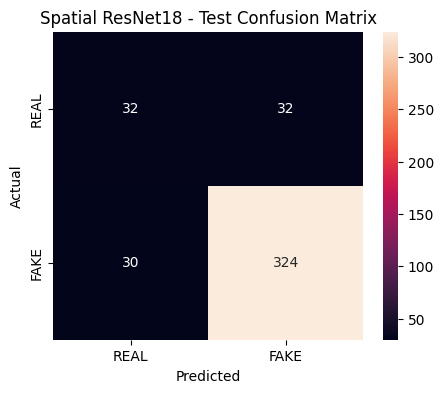

In [32]:
import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spatial ResNet18 - Test Confusion Matrix")

plt.show()

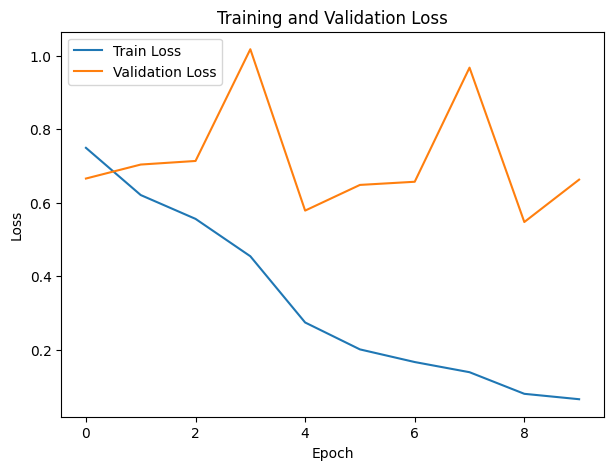

In [33]:
plt.figure(figsize=(7, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

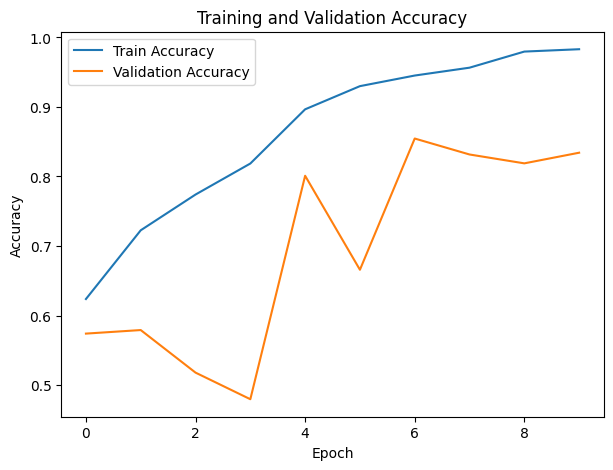

In [34]:
plt.figure(figsize=(7, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()